# EMS Risk Dashboard — Shift-Level Predictions for NYC Emergency Medical Services

**Goal:** Use our trained Logistic Regression model to generate actionable risk predictions for EMS dispatchers.

**Model:** Logistic Regression (best recall = 0.73) trained on 2022–2023, predicting on 2024–2026.

This notebook produces:
1. Trained LR model with predicted risk probabilities
2. Shift-level risk scores by borough and time of day
3. Top-10 highest-risk zones per shift
4. Breakdown by road user type (pedestrians, cyclists, motorists)
5. Visual dashboard for EMS planning

In [13]:
%pip install pandas numpy scikit-learn matplotlib seaborn statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print('Libraries loaded.')


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Libraries loaded.


In [14]:
# Load clean dataset
df = pd.read_csv('../data/collisions_clean.csv')
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')

# Target variable
df['target_severity'] = df['severity'].apply(lambda x: 1 if x in ['Injury', 'Fatal'] else 0)

# Temporal features
df['day_of_week'] = df['CRASH DATE'].dt.dayofweek
df['month'] = df['CRASH DATE'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_name'] = df['day_of_week'].map(dict(enumerate(day_names)))

def time_interval(hour):
    if pd.isna(hour): return 'Unknown'
    hour = int(hour)
    if 6 <= hour <= 9:     return 'Morning Rush (6-9AM)'
    elif 10 <= hour <= 15: return 'Midday (10AM-3PM)'
    elif 16 <= hour <= 19: return 'Evening Rush (4-7PM)'
    elif 20 <= hour <= 23: return 'Night (8PM-11PM)'
    else:                  return 'Late Night (12-5AM)'

df['time_interval'] = df['hour'].apply(time_interval)

def get_season(month):
    if month in [12,1,2]: return 'Winter'
    elif month in [3,4,5]: return 'Spring'
    elif month in [6,7,8]: return 'Summer'
    else: return 'Fall'

df['season'] = df['month'].apply(get_season)

print(f'Dataset loaded: {len(df):,} records')
print(f'Date range: {df["CRASH DATE"].min().date()} to {df["CRASH DATE"].max().date()}')

Dataset loaded: 375,025 records
Date range: 2022-02-03 to 2026-01-30


## 1. Train Logistic Regression Model
Train on 2022-2023, predict on 2024-2026 — real temporal forecasting.

In [15]:
# Fill NaN categoricals
df['BOROUGH'] = df['BOROUGH'].fillna('Unknown')
df['vehicle_type_clean'] = df['vehicle_type_clean'].fillna('Unknown')
df['season'] = df['season'].fillna('Unknown')

# One-hot encode
cat_cols = ['BOROUGH', 'vehicle_type_clean', 'season', 'time_interval']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Temporal train/test split
temporal_cutoff = pd.to_datetime('2024-01-01')
train_df = df_encoded[df_encoded['CRASH DATE'] < temporal_cutoff].copy()
test_df  = df_encoded[df_encoded['CRASH DATE'] >= temporal_cutoff].copy()

# Feature columns
exclude_cols = [
    'CRASH DATE', 'severity', 'target_severity', 'total_casualties',
    'has_injury', 'has_fatality', 'has_pedestrian_casualty', 'has_cyclist_casualty',
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
    'LATITUDE', 'LONGITUDE', 'primary_factor',
    'day_name', 'ON STREET NAME', 'CROSS STREET NAME'
]

feature_cols = [
    c for c in df_encoded.columns
    if c not in exclude_cols
    and df_encoded[c].dtype in ['int64', 'float64', 'uint8', 'bool']
]

X_train = train_df[feature_cols].fillna(0)
X_test  = test_df[feature_cols].fillna(0)
y_train = train_df['target_severity']
y_test  = test_df['target_severity']

print(f'Train: {X_train.shape[0]:,} records | Test: {X_test.shape[0]:,} records')
print(f'Features: {X_train.shape[1]}')

Train: 192,037 records | Test: 182,988 records
Features: 29


In [16]:
# Train Logistic Regression — best model (highest recall for EMS)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # handles class imbalance
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

# Predictions — y_prob is the key output: risk score per crash
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print('Model trained successfully.')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}  <- most important for EMS')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'F1:        {f1_score(y_test, y_pred):.3f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_prob):.3f}')

Model trained successfully.
Recall:    0.770  <- most important for EMS
Precision: 0.478
F1:        0.590
ROC AUC:   0.617


## 2. Attach Predicted Risk Scores to Each Crash

In [17]:
# Add model predictions back to test set
test_df = test_df.copy()
test_df['predicted_risk'] = y_prob      # probability 0-1
test_df['predicted_severe'] = y_pred    # binary 0/1

# Re-attach readable columns from original df
test_df['BOROUGH_orig']       = df.loc[test_df.index, 'BOROUGH']
test_df['time_interval_orig'] = df.loc[test_df.index, 'time_interval']
test_df['day_name']           = df.loc[test_df.index, 'day_name']
test_df['ped_injured']        = df.loc[test_df.index, 'NUMBER OF PEDESTRIANS INJURED']
test_df['cyclist_injured']    = df.loc[test_df.index, 'NUMBER OF CYCLIST INJURED']
test_df['motorist_injured']   = df.loc[test_df.index, 'NUMBER OF MOTORIST INJURED']
test_df['CRASH_DATE_orig']    = df.loc[test_df.index, 'CRASH DATE']

print(f'Test crashes with risk scores: {len(test_df):,}')
print(f'\nSample — crash + predicted risk:')
print(test_df[['BOROUGH_orig','time_interval_orig','day_name','predicted_risk','target_severity']].head(8).to_string())

Test crashes with risk scores: 182,988

Sample — crash + predicted risk:
       BOROUGH_orig    time_interval_orig day_name  predicted_risk  target_severity
192037     BROOKLYN  Evening Rush (4-7PM)   Monday        0.505339                0
192038      Unknown     Midday (10AM-3PM)   Monday        0.556548                1
192039     BROOKLYN      Night (8PM-11PM)   Monday        0.561250                1
192040       QUEENS  Morning Rush (6-9AM)   Monday        0.419155                0
192041      Unknown  Evening Rush (4-7PM)   Monday        0.528826                0
192042       QUEENS   Late Night (12-5AM)   Monday        0.936117                1
192043     BROOKLYN   Late Night (12-5AM)   Monday        0.477368                0
192044       QUEENS     Midday (10AM-3PM)   Monday        0.535086                0


## 3. Aggregate to Shift-Level Risk Scores

In [18]:
# Filter unknown borough and time
test_known = test_df[
    (test_df['BOROUGH_orig'] != 'Unknown') &
    (test_df['BOROUGH_orig'].notna()) &
    (test_df['time_interval_orig'] != 'Unknown')
].copy()

# Aggregate predicted risk by borough + time interval
shift_risk = test_known.groupby(['BOROUGH_orig', 'time_interval_orig']).agg(
    avg_predicted_risk  = ('predicted_risk', 'mean'),
    total_crashes       = ('predicted_risk', 'count'),
    predicted_severe    = ('predicted_severe', 'sum'),
    actual_severe       = ('target_severity', 'sum'),
    actual_injury_rate  = ('target_severity', 'mean'),
    ped_involved        = ('ped_injured', lambda x: (x > 0).sum()),
    cyclist_involved    = ('cyclist_injured', lambda x: (x > 0).sum())
).reset_index()

shift_risk.columns = [
    'Borough', 'Time Window', 'Predicted Risk', 'Total Crashes',
    'Predicted Severe', 'Actual Severe', 'Actual Injury Rate',
    'Ped Involved', 'Cyclist Involved'
]

def risk_cat(score):
    if score >= 0.55:   return 'HIGH'
    elif score >= 0.45: return 'MEDIUM'
    else:               return 'LOW'

shift_risk['Risk Level'] = shift_risk['Predicted Risk'].apply(risk_cat)
shift_risk = shift_risk.sort_values('Predicted Risk', ascending=False)

print(f'Shift combinations: {len(shift_risk)}')
print(f'\nRisk distribution:')
print(shift_risk['Risk Level'].value_counts())

Shift combinations: 25

Risk distribution:
Risk Level
MEDIUM    14
HIGH      11
Name: count, dtype: int64


## 4. Top-10 Highest Risk Zones for EMS Deployment

In [19]:
top10 = shift_risk[shift_risk['Total Crashes'] >= 10].head(10)

print('=' * 75)
print('TOP 10 HIGHEST RISK ZONES — EMS DEPLOYMENT RECOMMENDATIONS')
print('=' * 75)
print(f'{"Rank":<5} {"Borough":<15} {"Time Window":<25} {"Predicted Risk":<17} {"Risk Level"}')
print('-' * 75)
for i, (_, row) in enumerate(top10.iterrows(), 1):
    print(f'{i:<5} {row["Borough"]:<15} {row["Time Window"]:<25} {row["Predicted Risk"]:.1%}{"":<10} {row["Risk Level"]}')

print('\n* Predicted Risk = LR model predicted probability of injury/fatality')
print('* Trained on 2022-2023 | Tested on 2024-2026')

TOP 10 HIGHEST RISK ZONES — EMS DEPLOYMENT RECOMMENDATIONS
Rank  Borough         Time Window               Predicted Risk    Risk Level
---------------------------------------------------------------------------
1     BROOKLYN        Evening Rush (4-7PM)      60.9%           HIGH
2     BROOKLYN        Night (8PM-11PM)          60.3%           HIGH
3     QUEENS          Evening Rush (4-7PM)      59.8%           HIGH
4     BRONX           Evening Rush (4-7PM)      59.0%           HIGH
5     QUEENS          Night (8PM-11PM)          58.8%           HIGH
6     BRONX           Night (8PM-11PM)          58.7%           HIGH
7     MANHATTAN       Evening Rush (4-7PM)      58.4%           HIGH
8     MANHATTAN       Night (8PM-11PM)          57.7%           HIGH
9     STATEN ISLAND   Evening Rush (4-7PM)      56.3%           HIGH
10    STATEN ISLAND   Night (8PM-11PM)          55.8%           HIGH

* Predicted Risk = LR model predicted probability of injury/fatality
* Trained on 2022-2023 | Tes

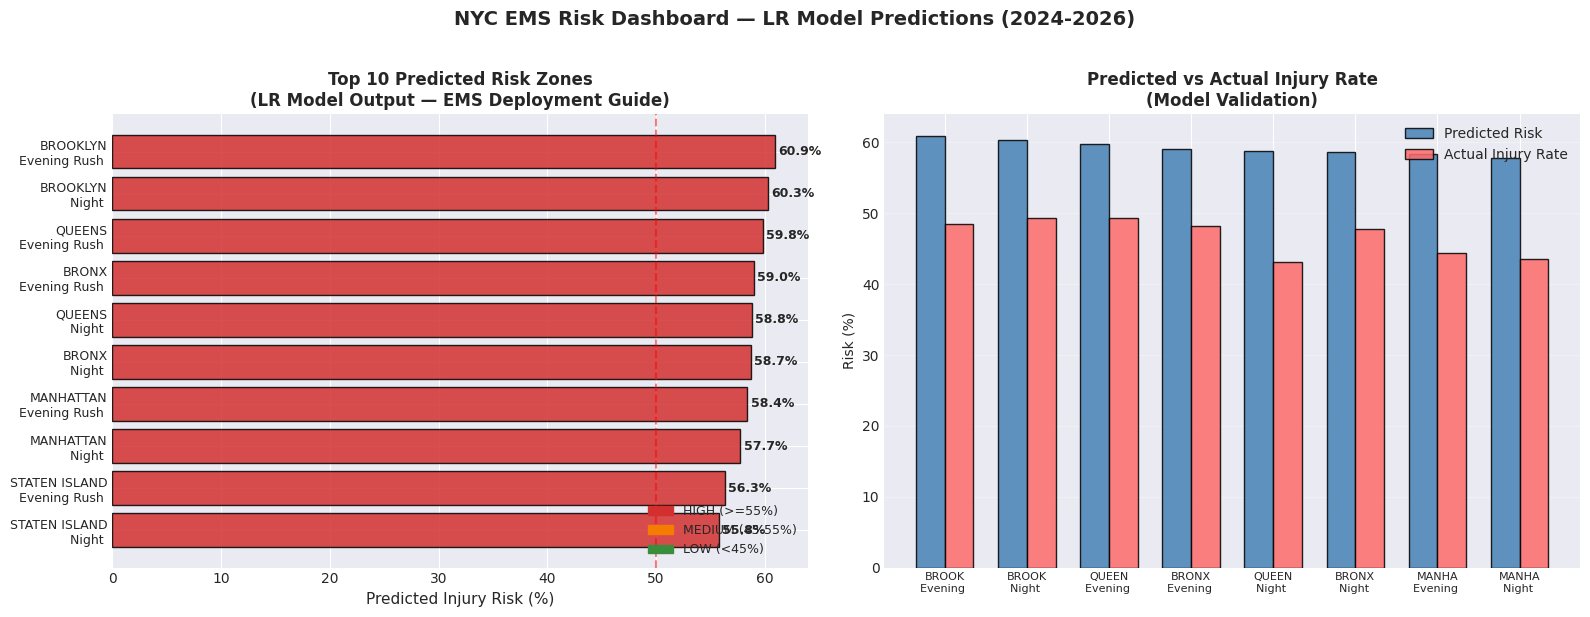

In [20]:
# Visualize Top 10 + Predicted vs Actual comparison
top10['label'] = top10['Borough'] + '\n' + top10['Time Window'].str.split('(').str[0]
colors = ['#d32f2f' if r == 'HIGH' else '#f57c00' if r == 'MEDIUM' else '#388e3c'
          for r in top10['Risk Level']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Top 10 predicted risk bar chart
bars = axes[0].barh(range(len(top10)), top10['Predicted Risk'] * 100,
                    color=colors, edgecolor='black', alpha=0.85)
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels(top10['label'], fontsize=9)
axes[0].set_xlabel('Predicted Injury Risk (%)', fontsize=11)
axes[0].set_title('Top 10 Predicted Risk Zones\n(LR Model Output — EMS Deployment Guide)', fontweight='bold')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5)
axes[0].invert_yaxis()
for bar, val in zip(bars, top10['Predicted Risk']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=9, fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#d32f2f', label='HIGH (>=55%)'),
    mpatches.Patch(color='#f57c00', label='MEDIUM (45-55%)'),
    mpatches.Patch(color='#388e3c', label='LOW (<45%)'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=9)

# Right: Predicted vs Actual injury rate
comparison = shift_risk[shift_risk['Total Crashes'] >= 20].head(8)
x = np.arange(len(comparison))
width = 0.35
axes[1].bar(x - width/2, comparison['Predicted Risk'] * 100, width,
            label='Predicted Risk', color='steelblue', alpha=0.85, edgecolor='black')
axes[1].bar(x + width/2, comparison['Actual Injury Rate'] * 100, width,
            label='Actual Injury Rate', color='#FF6B6B', alpha=0.85, edgecolor='black')
axes[1].set_xticks(x)
short_labels = [f"{r['Borough'][:5]}\n{r['Time Window'].split('(')[0][:8]}" for _, r in comparison.iterrows()]
axes[1].set_xticklabels(short_labels, fontsize=8)
axes[1].set_ylabel('Risk (%)')
axes[1].set_title('Predicted vs Actual Injury Rate\n(Model Validation)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('NYC EMS Risk Dashboard — LR Model Predictions (2024-2026)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Risk Heatmap — Borough x Time of Day

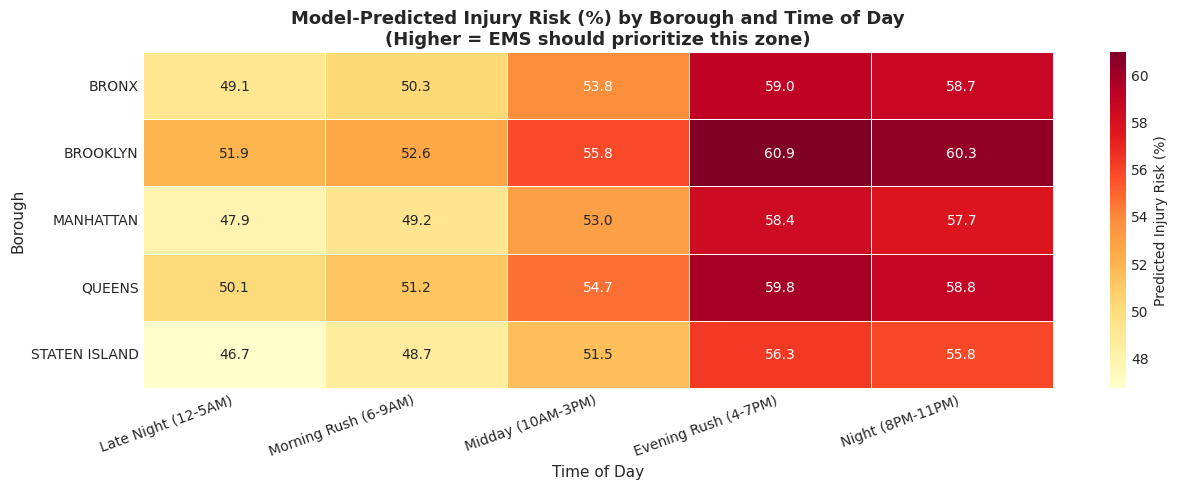

In [21]:
time_order = [
    'Late Night (12-5AM)',
    'Morning Rush (6-9AM)',
    'Midday (10AM-3PM)',
    'Evening Rush (4-7PM)',
    'Night (8PM-11PM)'
]

heatmap_data = test_known.groupby(
    ['BOROUGH_orig', 'time_interval_orig']
)['predicted_risk'].mean().unstack() * 100

heatmap_data = heatmap_data[[t for t in time_order if t in heatmap_data.columns]]

plt.figure(figsize=(13, 5))
sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Predicted Injury Risk (%)'}
)
plt.title('Model-Predicted Injury Risk (%) by Borough and Time of Day\n(Higher = EMS should prioritize this zone)',
          fontsize=13, fontweight='bold')
plt.xlabel('Time of Day', fontsize=11)
plt.ylabel('Borough', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Road User Type Breakdown

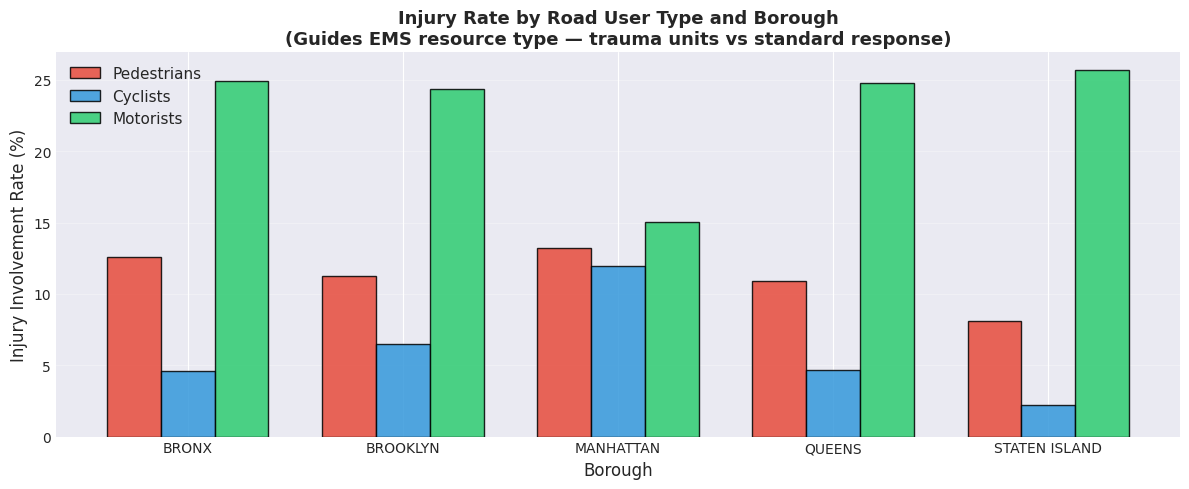

In [22]:
borough_user = test_known.groupby('BOROUGH_orig').agg(
    ped_rate      = ('ped_injured',      lambda x: (x > 0).mean()),
    cyclist_rate  = ('cyclist_injured',  lambda x: (x > 0).mean()),
    motorist_rate = ('motorist_injured', lambda x: (x > 0).mean())
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(borough_user))
width = 0.25

ax.bar(x - width, borough_user['ped_rate'] * 100,      width, label='Pedestrians', color='#E74C3C', alpha=0.85, edgecolor='black')
ax.bar(x,         borough_user['cyclist_rate'] * 100,  width, label='Cyclists',    color='#3498DB', alpha=0.85, edgecolor='black')
ax.bar(x + width, borough_user['motorist_rate'] * 100, width, label='Motorists',   color='#2ECC71', alpha=0.85, edgecolor='black')

ax.set_xlabel('Borough', fontsize=12)
ax.set_ylabel('Injury Involvement Rate (%)', fontsize=12)
ax.set_title('Injury Rate by Road User Type and Borough\n(Guides EMS resource type — trauma units vs standard response)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(borough_user['BOROUGH_orig'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Poisson Regression — Expected Crash Counts per Shift
LR tells us **how dangerous** a zone is. Poisson tells us **how many crashes** to expect.
Combined: EMS knows both the risk level AND the volume.

In [23]:
import statsmodels.api as sm

# Aggregate collision counts by borough + day_of_week + time_interval + month
df_poisson = df[
    (df['BOROUGH'] != 'Unknown') &
    (df['BOROUGH'].notna()) &
    (df['time_interval'] != 'Unknown')
].copy()

collision_counts = df_poisson.groupby(
    ['BOROUGH', 'day_of_week', 'time_interval', 'month', 'is_weekend']
).agg(
    collision_count=('target_severity', 'count'),
    injury_count=('target_severity', 'sum'),
    year=('CRASH DATE', lambda x: x.dt.year.max())
).reset_index()

print(f'Aggregated groups: {len(collision_counts):,}')
print(f'Collision count stats:')
print(collision_counts['collision_count'].describe())

Aggregated groups: 2,100
Collision count stats:
count    2100.000000
mean      127.368571
std        86.738184
min         4.000000
25%        58.000000
50%       113.500000
75%       176.000000
max       475.000000
Name: collision_count, dtype: float64


In [32]:
print(f'collision_counts shape: {collision_counts.shape}')
print(f'years: {sorted(collision_counts["year"].unique())}')
print(f'train_mask sum: {train_mask.sum()}')
print(f'test_mask sum: {test_mask.sum()}')

collision_counts shape: (2100, 8)
years: [np.int32(2024), np.int32(2025), np.int32(2026)]
train_mask sum: 0
test_mask sum: 2100


In [30]:
# Fit Poisson GLM
X_p_train_c = sm.add_constant(X_p_train)

In [34]:
import statsmodels.api as sm

# Aggregate collision counts — split BEFORE aggregating
df_poisson = df[
    (df['BOROUGH'] != 'Unknown') &
    (df['BOROUGH'].notna()) &
    (df['time_interval'] != 'Unknown')
].copy()

temporal_cutoff = pd.to_datetime('2024-01-01')

df_poisson_train = df_poisson[df_poisson['CRASH DATE'] < temporal_cutoff]
df_poisson_test  = df_poisson[df_poisson['CRASH DATE'] >= temporal_cutoff]

print(f'Train records: {len(df_poisson_train):,}')
print(f'Test records:  {len(df_poisson_test):,}')

def aggregate_counts(data):
    return data.groupby(
        ['BOROUGH', 'day_of_week', 'time_interval', 'month', 'is_weekend']
    ).agg(
        collision_count=('target_severity', 'count'),
        injury_count=('target_severity', 'sum')
    ).reset_index()

train_counts = aggregate_counts(df_poisson_train)
test_counts  = aggregate_counts(df_poisson_test)

print(f'Train groups: {len(train_counts):,}')
print(f'Test groups:  {len(test_counts):,}')

Train records: 128,950
Test records:  138,524
Train groups: 2,098
Test groups:  2,100


In [38]:
# Encode for Poisson
def encode_counts(data):
    return pd.get_dummies(
        data,
        columns=['BOROUGH', 'time_interval'],
        drop_first=True
    )

train_encoded = encode_counts(train_counts)
test_encoded  = encode_counts(test_counts)

# Align columns — test might be missing some columns from train
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

poisson_features = [
    c for c in train_encoded.columns
    if c not in ['collision_count', 'injury_count']
    and train_encoded[c].dtype in ['int64', 'float64', 'uint8', 'bool']
]

X_p_train = train_encoded[poisson_features].astype(float)
X_p_test  = test_encoded[poisson_features].astype(float)
y_p_train = train_encoded['collision_count']
y_p_test  = test_encoded['collision_count']

print(f'X_p_train shape: {X_p_train.shape}')
print(f'X_p_test shape:  {X_p_test.shape}')

# Fit Poisson GLM
X_p_train_c = sm.add_constant(X_p_train)
X_p_test_c  = sm.add_constant(X_p_test)

poisson_model = sm.GLM(
    y_p_train,
    X_p_train_c,
    family=sm.families.Poisson()
).fit()

y_p_pred = poisson_model.predict(X_p_test_c)

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_p_test, y_p_pred)
mean_actual = y_p_test.mean()

print(f'Poisson MAE: {mae:.2f}')
print(f'Mean actual count: {mean_actual:.2f}')
print(f'MAE as % of mean: {mae/mean_actual*100:.1f}%')

X_p_train shape: (2098, 9)
X_p_test shape:  (2100, 9)
Poisson MAE: 14.27
Mean actual count: 65.96
MAE as % of mean: 21.6%


In [39]:
# Combine LR risk score + Poisson count into one EMS table
test_encoded['BOROUGH_orig']       = test_counts['BOROUGH'].values
test_encoded['time_interval_orig'] = test_counts['time_interval'].values
test_encoded['predicted_count']    = y_p_pred.values

poisson_summary = test_encoded.groupby(
    ['BOROUGH_orig', 'time_interval_orig']
).agg(
    avg_predicted_count=('predicted_count', 'mean'),
    avg_actual_count=('collision_count', 'mean')
).reset_index()

poisson_summary.columns = ['Borough', 'Time Window', 'Predicted Crashes/shift', 'Actual Crashes/shift']

# Merge with LR risk scores
combined = shift_risk.merge(
    poisson_summary,
    on=['Borough', 'Time Window'],
    how='left'
)
combined = combined.sort_values('Predicted Risk', ascending=False)

print('=' * 90)
print('COMBINED EMS TABLE: Risk Score (LR) + Expected Crashes (Poisson)')
print('=' * 90)
print(f'{"Borough":<15} {"Time Window":<25} {"Pred Risk":<12} {"Exp Crashes":<14} {"Risk Level"}')
print('-' * 90)
for _, row in combined[combined['Total Crashes'] >= 10].head(12).iterrows():
    exp = f"{row['Predicted Crashes/shift']:.1f}" if pd.notna(row.get('Predicted Crashes/shift')) else 'N/A'
    print(f'{row["Borough"]:<15} {str(row["Time Window"])[:23]:<25} {row["Predicted Risk"]:.1%}{"":<5} {exp:<14} {row["Risk Level"]}')

print('\n* Pred Risk    = LR model: probability of injury/fatality')
print('* Exp Crashes  = Poisson model: expected number of crashes per shift')
print('* Use BOTH: high risk + high volume zones = top EMS priority')

COMBINED EMS TABLE: Risk Score (LR) + Expected Crashes (Poisson)
Borough         Time Window               Pred Risk    Exp Crashes    Risk Level
------------------------------------------------------------------------------------------
BROOKLYN        Evening Rush (4-7PM)      60.9%      124.1          HIGH
BROOKLYN        Night (8PM-11PM)          60.3%      80.2           HIGH
QUEENS          Evening Rush (4-7PM)      59.8%      97.1           HIGH
BRONX           Evening Rush (4-7PM)      59.0%      60.8           HIGH
QUEENS          Night (8PM-11PM)          58.8%      62.7           HIGH
BRONX           Night (8PM-11PM)          58.7%      39.3           HIGH
MANHATTAN       Evening Rush (4-7PM)      58.4%      64.3           HIGH
MANHATTAN       Night (8PM-11PM)          57.7%      41.5           HIGH
STATEN ISLAND   Evening Rush (4-7PM)      56.3%      14.6           HIGH
STATEN ISLAND   Night (8PM-11PM)          55.8%      9.5            HIGH
BROOKLYN        Midday (10AM-3PM)

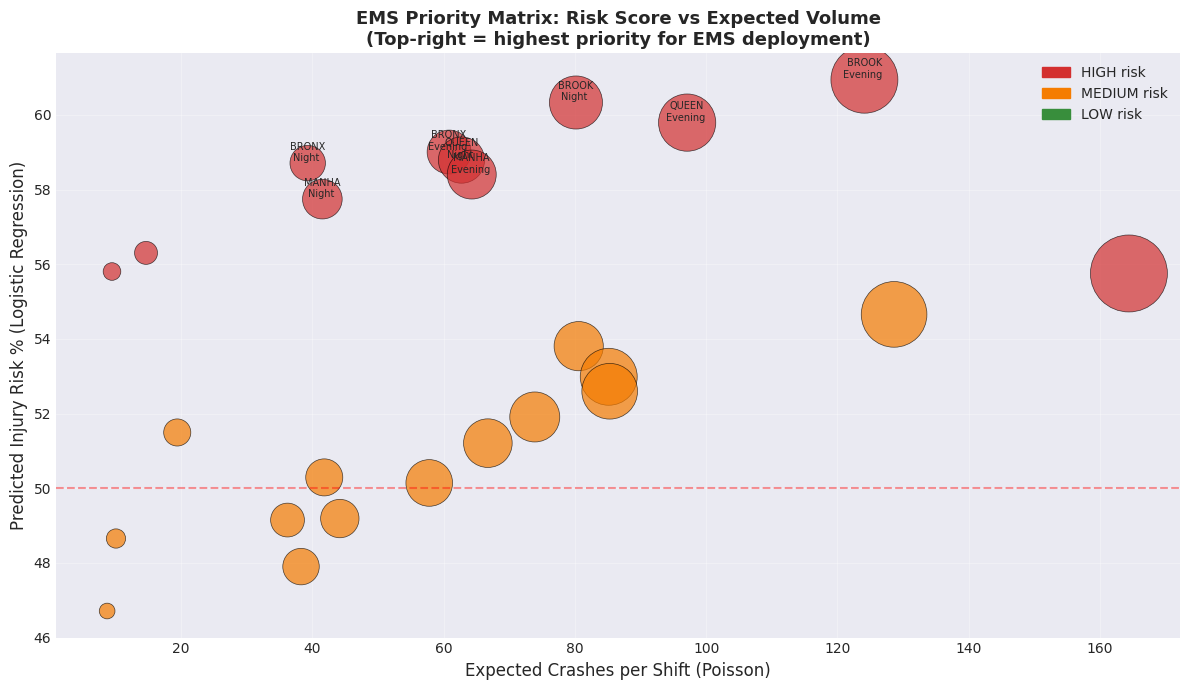

Top-right corner = HIGH risk + HIGH volume = EMS should always have units here


In [40]:
# Visualize combined output: bubble chart — risk score vs expected crashes
plot_df = combined[
    (combined['Total Crashes'] >= 10) &
    (combined['Predicted Crashes/shift'].notna())
].copy()

color_map = {'HIGH': '#d32f2f', 'MEDIUM': '#f57c00', 'LOW': '#388e3c'}
colors_bubble = [color_map[r] for r in plot_df['Risk Level']]

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    plot_df['Predicted Crashes/shift'],
    plot_df['Predicted Risk'] * 100,
    c=colors_bubble,
    s=plot_df['Total Crashes'] / 5,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Label top points
for _, row in plot_df.head(8).iterrows():
    plt.annotate(
        f"{row['Borough'][:5]}\n{row['Time Window'].split('(')[0][:8]}",
        (row['Predicted Crashes/shift'], row['Predicted Risk'] * 100),
        fontsize=7, ha='center', va='bottom'
    )

plt.axhline(y=50, color='red', linestyle='--', alpha=0.4, label='50% risk threshold')
plt.xlabel('Expected Crashes per Shift (Poisson)', fontsize=12)
plt.ylabel('Predicted Injury Risk % (Logistic Regression)', fontsize=12)
plt.title('EMS Priority Matrix: Risk Score vs Expected Volume\n(Top-right = highest priority for EMS deployment)',
          fontsize=13, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#d32f2f', label='HIGH risk'),
    mpatches.Patch(color='#f57c00', label='MEDIUM risk'),
    mpatches.Patch(color='#388e3c', label='LOW risk'),
]
plt.legend(handles=legend_patches, fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Top-right corner = HIGH risk + HIGH volume = EMS should always have units here')

## 8. Final EMS Shift Planning Summary

In [41]:
final_summary = shift_risk[shift_risk['Total Crashes'] >= 10].copy()
final_summary = final_summary.sort_values('Predicted Risk', ascending=False)

n_weeks = max(
    (test_df['CRASH_DATE_orig'].max() - test_df['CRASH_DATE_orig'].min()).days / 7, 1
)
final_summary['Crashes/week'] = (final_summary['Total Crashes'] / n_weeks).round(1)

print('=' * 80)
print('EMS SHIFT PLANNING SUMMARY — MODEL-BASED RECOMMENDATIONS')
print('=' * 80)
print(f'{"Borough":<15} {"Time Window":<25} {"Pred Risk":<12} {"Crashes/wk":<13} {"Risk Level"}')
print('-' * 80)
for _, row in final_summary.head(15).iterrows():
    print(f'{row["Borough"]:<15} {str(row["Time Window"])[:23]:<25} {row["Predicted Risk"]:.1%}{"":<5} {row["Crashes/week"]:<13} {row["Risk Level"]}')

print('\n* Pred Risk  = LR model predicted probability of injury/fatality')
print('* Crashes/wk = average number of crashes per week in this zone/time')
print('* Action     = pre-position EMS units in HIGH zones before shift start')

EMS SHIFT PLANNING SUMMARY — MODEL-BASED RECOMMENDATIONS
Borough         Time Window               Pred Risk    Crashes/wk    Risk Level
--------------------------------------------------------------------------------
BROOKLYN        Evening Rush (4-7PM)      60.9%      107.1         HIGH
BROOKLYN        Night (8PM-11PM)          60.3%      67.3          HIGH
QUEENS          Evening Rush (4-7PM)      59.8%      78.3          HIGH
BRONX           Evening Rush (4-7PM)      59.0%      46.0          HIGH
QUEENS          Night (8PM-11PM)          58.8%      51.1          HIGH
BRONX           Night (8PM-11PM)          58.7%      30.0          HIGH
MANHATTAN       Evening Rush (4-7PM)      58.4%      57.3          HIGH
MANHATTAN       Night (8PM-11PM)          57.7%      37.6          HIGH
STATEN ISLAND   Evening Rush (4-7PM)      56.3%      12.6          HIGH
STATEN ISLAND   Night (8PM-11PM)          55.8%      7.4           HIGH
BROOKLYN        Midday (10AM-3PM)         55.8%      141.4    

In [45]:
# ================================================================
# EMS SHIFT FORECAST — Full prediction per shift
# Output: for each borough + shift → expected crashes + all risks
# ================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# --- Train separate models for each road user type ---
df_model = df[
    (df['BOROUGH'] != 'Unknown') &
    (df['BOROUGH'].notna()) &
    (df['time_interval'] != 'Unknown')
].copy()

df_model['target_ped']      = (df_model['NUMBER OF PEDESTRIANS INJURED'] > 0).astype(int)
df_model['target_cyclist']  = (df_model['NUMBER OF CYCLIST INJURED'] > 0).astype(int)
df_model['target_motorist'] = (df_model['NUMBER OF MOTORIST INJURED'] > 0).astype(int)
df_model['target_fatal']    = (df_model['NUMBER OF PERSONS KILLED'] > 0).astype(int)

# Encode
df_model_enc = pd.get_dummies(
    df_model,
    columns=['BOROUGH', 'vehicle_type_clean', 'season', 'time_interval'],
    drop_first=True
)

temporal_cutoff = pd.to_datetime('2024-01-01')
train_m = df_model_enc[df_model_enc['CRASH DATE'] < temporal_cutoff]
test_m  = df_model_enc[df_model_enc['CRASH DATE'] >= temporal_cutoff]

exclude = [
    'CRASH DATE', 'severity', 'target_severity',
    'target_ped', 'target_cyclist', 'target_motorist', 'target_fatal',
    'total_casualties', 'has_injury', 'has_fatality',
    'has_pedestrian_casualty', 'has_cyclist_casualty',
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
    'LATITUDE', 'LONGITUDE', 'primary_factor',
    'day_name', 'ON STREET NAME', 'CROSS STREET NAME'
]

feat_cols = [
    c for c in df_model_enc.columns
    if c not in exclude
    and df_model_enc[c].dtype in ['int64', 'float64', 'uint8', 'bool']
]

X_tr = train_m[feat_cols].fillna(0)
X_te = test_m[feat_cols].fillna(0)

scaler2 = StandardScaler()
X_tr_sc = scaler2.fit_transform(X_tr)
X_te_sc = scaler2.transform(X_te)

# Train one model per target
models = {}
for target in ['target_severity', 'target_ped', 'target_cyclist', 'target_motorist', 'target_fatal']:
    y_tr = train_m[target] if target in train_m.columns else df_model_enc.loc[train_m.index, target]
    m = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    m.fit(X_tr_sc, y_tr)
    models[target] = m
    print(f'Trained: {target}')

print('All models trained.')

Trained: target_severity
Trained: target_ped
Trained: target_cyclist
Trained: target_motorist
Trained: target_fatal
All models trained.


In [46]:
# --- Aggregate predictions per shift ---
test_m2 = test_m.copy()
test_m2['BOROUGH_orig']       = df_model.loc[test_m.index, 'BOROUGH']
test_m2['time_interval_orig'] = df_model.loc[test_m.index, 'time_interval']
test_m2['day_name']           = df_model.loc[test_m.index, 'day_name']

for target, model in models.items():
    test_m2[f'prob_{target}'] = model.predict_proba(X_te_sc)[:, 1]

# Aggregate by borough + day + time interval
shift_forecast = test_m2.groupby(
    ['BOROUGH_orig', 'day_name', 'time_interval_orig']
).agg(
    total_crashes        = ('prob_target_severity', 'count'),
    injury_risk          = ('prob_target_severity', 'mean'),
    pedestrian_risk      = ('prob_target_ped',      'mean'),
    cyclist_risk         = ('prob_target_cyclist',  'mean'),
    motorist_risk        = ('prob_target_motorist', 'mean'),
).reset_index()

shift_forecast.columns = [
    'Borough', 'Day', 'Time Window',
    'Expected Crashes', 'Injury Risk %',
    'Pedestrian Risk %', 'Cyclist Risk %', 'Motorist Risk %'
]

# Convert to percentages
for col in ['Injury Risk %', 'Pedestrian Risk %', 'Cyclist Risk %', 'Motorist Risk %']:
    shift_forecast[col] = (shift_forecast[col] * 100).round(1)

shift_forecast = shift_forecast.sort_values('Injury Risk %', ascending=False)

print('=' * 100)
print('EMS SHIFT FORECAST — Full Risk Breakdown per Shift')
print('=' * 100)
print(f'{"Borough":<12} {"Day":<12} {"Time Window":<25} {"Crashes":<10} {"Injury%":<10} {"Ped%":<8} {"Cyclist%":<10} {"Motorist%"}')
print('-' * 100)
for _, row in shift_forecast.head(15).iterrows():
    print(
        f'{row["Borough"]:<12} {row["Day"]:<12} {str(row["Time Window"])[:23]:<25} '
        f'{row["Expected Crashes"]:<10} {row["Injury Risk %"]:<10} '
        f'{row["Pedestrian Risk %"]:<8} {row["Cyclist Risk %"]:<10} {row["Motorist Risk %"]}'
    )

print('\n* Injury Risk    = probability crash results in any injury/fatality')
print('* Pedestrian Risk = probability a pedestrian is injured')
print('* Cyclist Risk    = probability a cyclist is injured')
print('* Motorist Risk   = probability a motorist is injured')
print('* Use this table to decide: how many units, what type, where to deploy')

EMS SHIFT FORECAST — Full Risk Breakdown per Shift
Borough      Day          Time Window               Crashes    Injury%    Ped%     Cyclist%   Motorist%
----------------------------------------------------------------------------------------------------
BROOKLYN     Thursday     Evening Rush (4-7PM)      1810       63.8       37.0     51.8       54.2
BROOKLYN     Wednesday    Evening Rush (4-7PM)      1793       63.7       35.1     52.4       54.0
BROOKLYN     Monday       Evening Rush (4-7PM)      1651       63.7       37.6     51.8       52.9
BROOKLYN     Friday       Evening Rush (4-7PM)      1826       63.6       37.1     51.9       53.6
BROOKLYN     Tuesday      Evening Rush (4-7PM)      1803       63.6       38.3     51.7       52.7
QUEENS       Monday       Evening Rush (4-7PM)      1205       63.1       38.6     40.6       55.3
QUEENS       Friday       Evening Rush (4-7PM)      1348       62.9       36.6     40.9       56.0
QUEENS       Wednesday    Evening Rush (4-7PM)     

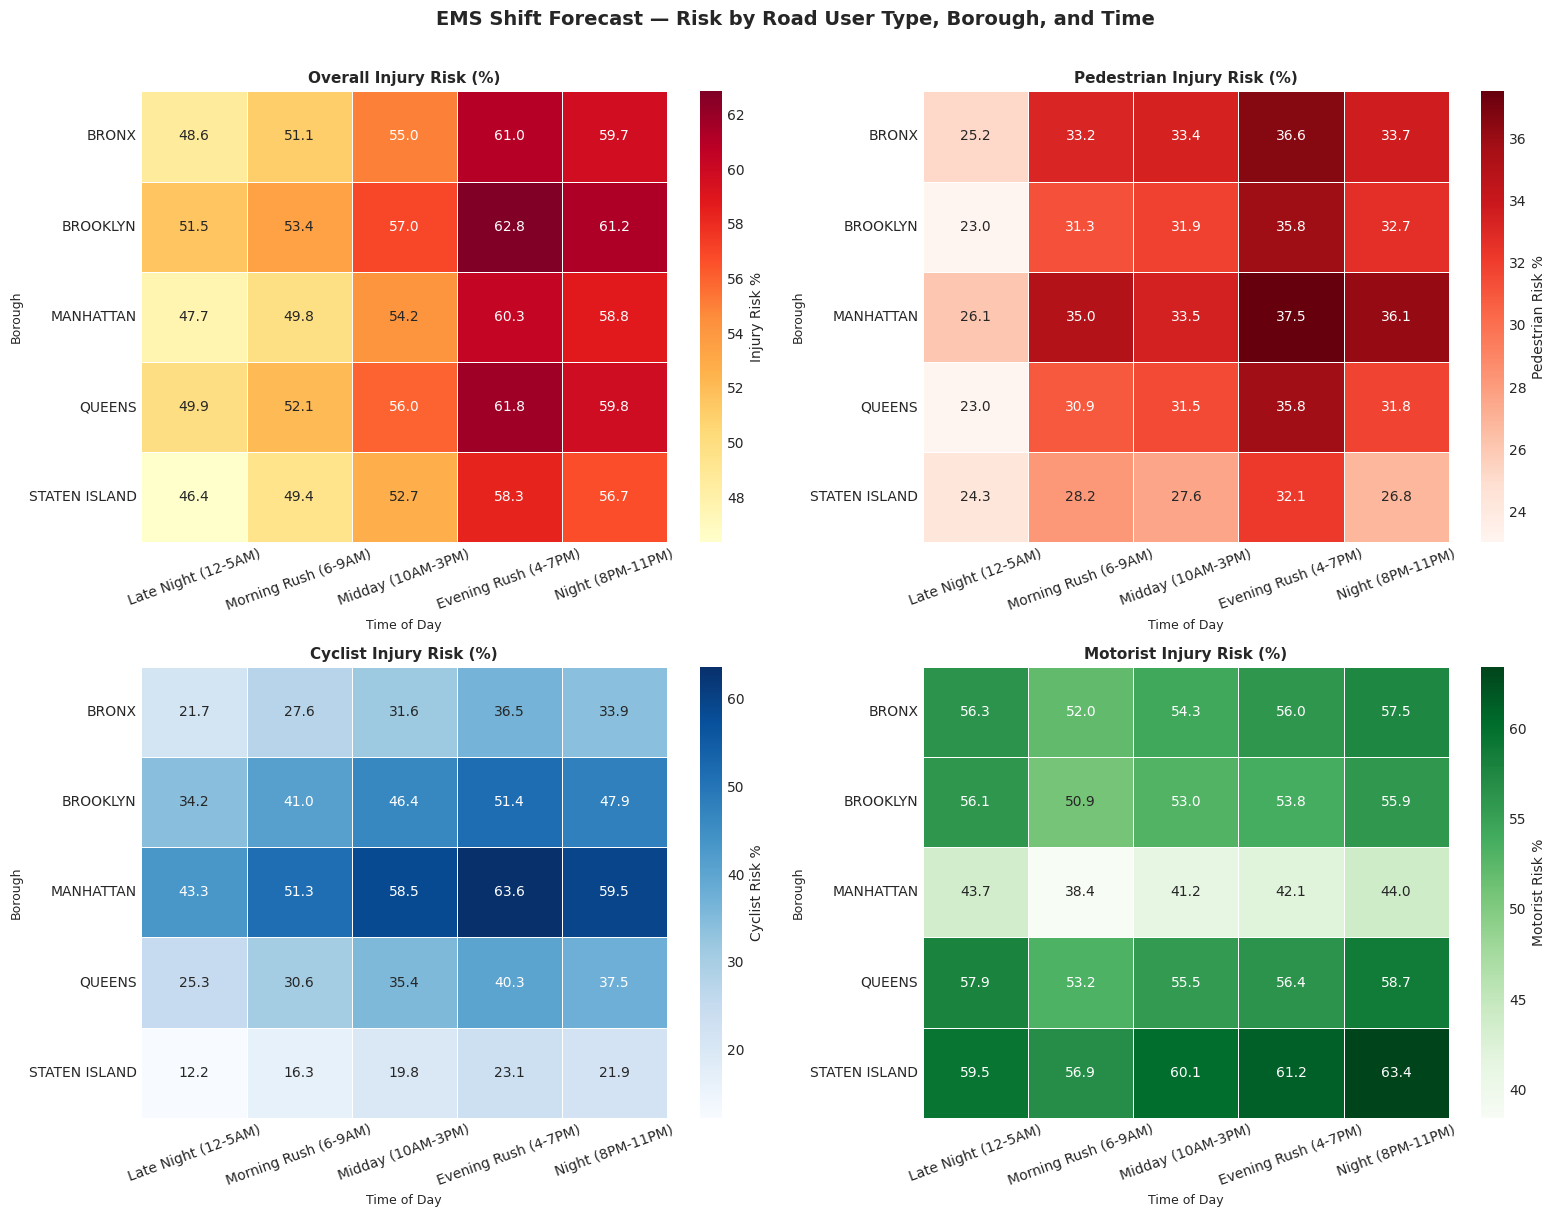

Top-right = highest priority. Red = deploy trauma units. Blue = watch for cyclists.


In [47]:
# --- Visualize shift forecast ---
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
time_order = ['Late Night (12-5AM)','Morning Rush (6-9AM)','Midday (10AM-3PM)',
              'Evening Rush (4-7PM)','Night (8PM-11PM)']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = [
    ('Injury Risk %',     'YlOrRd', 'Overall Injury Risk (%)'),
    ('Pedestrian Risk %', 'Reds',   'Pedestrian Injury Risk (%)'),
    ('Cyclist Risk %',    'Blues',  'Cyclist Injury Risk (%)'),
    ('Motorist Risk %',   'Greens', 'Motorist Injury Risk (%)'),
]

for ax, (metric, cmap, title) in zip(axes.flatten(), metrics):
    pivot = shift_forecast.groupby(
        ['Borough', 'Time Window']
    )[metric].mean().unstack()
    pivot = pivot[[t for t in time_order if t in pivot.columns]]
    sns.heatmap(
        pivot, annot=True, fmt='.1f', cmap=cmap,
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': metric}, ax=ax
    )
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Time of Day', fontsize=9)
    ax.set_ylabel('Borough', fontsize=9)
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('EMS Shift Forecast — Risk by Road User Type, Borough, and Time',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Top-right = highest priority. Red = deploy trauma units. Blue = watch for cyclists.')